In [1]:
import os
import optuna
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.stats import linregress

from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, precision_score, average_precision_score

## Crawl data

In [2]:
from vnstock import Vnstock
from vnstock.explorer.vci.listing import Listing

symbols_by_industries = Listing().symbols_by_industries()
symbols_by_exchange = Listing().symbols_by_exchange()
symbols_info = symbols_by_industries.merge(symbols_by_exchange)

In [3]:
symbols_list = symbols_info['symbol'].tolist()
data_count_save_path = './data/data_count.csv'

data_count = None
keep_symbols = None
if os.path.exists(data_count_save_path):
    data_count = pd.read_csv(data_count_save_path)

In [4]:
keep_symbols = []
data_count = []
all_data = {}
for symbol in tqdm(symbols_list):
    save_path = f'./data/stocks/{symbol}.csv'
    if os.path.exists(save_path):
        df = pd.read_csv(save_path)
    else:
        if data_count is not None:
            continue
        try:
            vn_stock = Vnstock()
            stock = vn_stock.stock(symbol=symbol, source='VCI')
            df = stock.quote.history(start='2020-01-01', end='2025-02-25')
            df.to_csv(f'./data/stocks/{symbol}.csv', index=False)
        except Exception as e:
            print(e)
            continue
    if (df['volume']*df['close']).values[-1].tolist() > 5e7:
        data_count.append([symbol, df.shape[0]])
        all_data[symbol] = df
        keep_symbols.append(symbol)
    

100%|██████████| 1591/1591 [00:01<00:00, 1031.06it/s]


In [5]:
if data_count is None:
    data_count = pd.DataFrame(data_count, columns=['symbol', 'count'])
    data_count.to_csv(data_count_save_path, index=False)

## Features Engineering

In [6]:
len(keep_symbols)

67

In [7]:
def feature_engineering(df):
    from talipp.ohlcv import OHLCVFactory
    from talipp.indicators import ADX, AO, Aroon, ATR, BOP, CHOP, CoppockCurve, DPO, EMV, IBS, \
        MACD, MassIndex, ROC, RSI, STC, Stoch, StochRSI, SuperTrend, TRIX, TSI, TTM, UO, VTX

    def incr_rate_estimate(x):
        d = len(x)
        lr = linregress(range(d), x/x.tolist()[-1])
        i = lr.intercept.tolist()
        s = lr.slope.tolist()
        if i == 0:
            return s*d
        return s*d/i

    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values(by='time')
    df['close_pct_change'] = df['close'].pct_change()
    df['close_open_diff'] = (df['close'] - df['open']) / df['open']
    df['high_low_diff'] = (df['high'] - df['low']) / df['low']
    df['close_low_diff'] = (df['close'] - df['low']) / df['low']
    df['volume_pct_change'] = df['volume'].pct_change()

    for col in ['close', 'volume']:
        for d in [5,10,20]:
            df[f'{col}_avg{d}'] = df[col].rolling(window=d).mean()
            df[f'cur_{col}_vs_avg{d}_diff'] = (df[col] - df[f'{col}_avg{d}']) / df[f'{col}_avg{d}']
            del df[f'{col}_avg{d}']

    for col in ['volume', 'close']:
        for d in [5, 10, 15]:
            df[f'{col}_slope{d}'] = df[col].rolling(d).apply(incr_rate_estimate)

    for col in ['volume', 'close']:
        df[f'{col}_slope5_vs_slope10_diff'] = (1+df[f'{col}_slope5']) / (1+df[f'{col}_slope10'])-1
        df[f'{col}_slope5_vs_slope15_diff'] = (1+df[f'{col}_slope5']) / (1+df[f'{col}_slope15'])-1
        df[f'{col}_slope10_vs_slope15_diff'] = (1+df[f'{col}_slope10']) / (1+df[f'{col}_slope15'])-1

    ohlcv = OHLCVFactory.from_dict({
        "open": df['open'],
        "high": df['high'],
        "low": df['low'],
        "close": df['close'],
        "volume": df['volume']
    })
    close = df['close']
    adx = ADX(10, 10, ohlcv)
    adx_plus_di = [adx_val.plus_di if adx_val is not None else None for adx_val in adx.output_values]
    adx_minus_di = [adx_val.minus_di if adx_val is not None else None for adx_val in adx.output_values]
    ao = AO(5, 34, ohlcv).output_values
    aroon = Aroon(10, ohlcv)
    aroon_up = [a.up if a is not None else None for a in aroon.output_values]
    aroon_down = [a.down if a is not None else None for a in aroon.output_values]
    atr = ATR(10, ohlcv).output_values
    bop = BOP(ohlcv).output_values
    chop = CHOP(10, ohlcv).output_values
    coppock_curve = CoppockCurve(11, 10, 10, close).output_values
    dpo = DPO(20, close).output_values
    emv = EMV(10, 10000, ohlcv).output_values
    ibs = IBS(ohlcv).output_values
    macd = MACD(12, 26, 9, close).output_values
    macd_hist = [m.histogram if m is not None else None for m in macd]
    macd_signal = [m.signal if m is not None else None for m in macd]
    macd_val = [m.macd if m is not None else None for m in macd]
    mass_index = MassIndex(9, 9, 10, ohlcv).output_values
    roc = ROC(9, close).output_values
    rsi = RSI(10, close).output_values
    stc = STC(23, 50, 10, 3, close).output_values
    stoch = Stoch(10, 3, ohlcv)
    stoch_k = [s.k if s is not None else None for s in stoch.output_values]
    stoch_d = [s.d if s is not None else None for s in stoch.output_values]
    stoch_rsi = StochRSI(10, 10, 3, 3, close)
    stoch_rsi_k = [s.k if s is not None else None for s in stoch_rsi.output_values]
    stoch_rsi_d = [s.d if s is not None else None for s in stoch_rsi.output_values]
    super_trend = [s.value if s is not None else None for s in SuperTrend(10, 3, ohlcv).output_values]
    trix = TRIX(18, close).output_values
    tsi = TSI(13, 25, close).output_values
    ttm = TTM(20, input_values = ohlcv)
    ttm_histogram = [t.histogram if t is not None else None for t in ttm.output_values]
    uo = UO(7, 10, 20, ohlcv).output_values
    vtx = VTX(10, ohlcv)
    vtx_plus = [v.plus_vtx if v is not None else None for v in vtx.output_values]
    vtx_minus = [v.minus_vtx if v is not None else None for v in vtx.output_values]
    df['adx_plus_di'] = adx_plus_di
    df['adx_minus_di'] = adx_minus_di
    df['ao'] = ao
    df['aroon_up'] = aroon_up
    df['aroon_down'] = aroon_down
    df['atr'] = atr
    df['bop'] = bop
    df['chop'] = chop
    df['coppock_curve'] = coppock_curve
    df['dpo'] = dpo
    df['emv'] = emv
    df['ibs'] = ibs
    df['macd_hist'] = macd_hist
    df['macd_signal'] = macd_signal
    df['macd_val'] = macd_val
    df['mass_index'] = mass_index
    df['roc'] = roc
    df['rsi'] = rsi
    df['stc'] = stc
    df['stoch_k'] = stoch_k
    df['stoch_d'] = stoch_d
    df['stoch_rsi_k'] = stoch_rsi_k
    df['stoch_rsi_d'] = stoch_rsi_d
    df['super_trend'] = super_trend
    df['trix'] = trix
    df['tsi'] = tsi
    df['ttm_histogram'] = ttm_histogram
    df['uo'] = uo
    df['vtx_plus'] = vtx_plus
    df['vtx_minus'] = vtx_minus
    
    shift_cols = [c for c in df.columns if c not in ['time', 'open', 'high', 'low', 'close', 'volume']]
    for shift_day in range(1,4):
        df[[f'prev{shift_day}d_{sc}' for sc in shift_cols]] = df.shift(shift_day)[shift_cols]

    return df

## Label

In [8]:
def label(df):
    upper_rate = 1.05
    # df['label'] = df['close'].shift(-3) / df['close'] - 1
    df['next_close'] = df['close'].shift(-3)
    df['label'] = df['next_close'] > df['close'] * upper_rate
    # df['label2'] = df['close'].shift(-3) > df['close']
    return df

In [9]:
# old_all_df = all_df.copy()
# all_df = old_all_df.copy()

In [10]:
all_df = []
c = 0
for symbol, df in all_data.items():
    print(symbol)
    df = feature_engineering(df)
    df = label(df)
    df['symbol'] = symbol
    all_df.append(df)
    c += 1

all_df = pd.concat(all_df)
all_df = all_df[all_df['volume']*all_df['close'] > 5e7].dropna()
# all_df = all_df[(all_df['cur_volume_vs_avg10_diff'].abs() > 0.5) | (all_df['prev1d_cur_volume_vs_avg10_diff'].abs() > 0.5) | (all_df['prev2d_cur_volume_vs_avg10_diff'].abs() > 0.5) | (all_df['prev3d_cur_volume_vs_avg10_diff'].abs() > 0.5)].reset_index(drop=True)

ACB
DGC
BID
ANV
BVB
CSV
BAF
FPT
HAH
HHV
CTG
CTI
EVF
GEX
HPG
DXG
TCH
CTR
DIG
DBC
EIB
HCM
KDH
GMD
MBB
KBC
LPB
MSN
MWG
NLG
HNG
BSR
HDB
ORS
PVD
PDR
POW
FRT
NKG
REE
NVL
VHM
PVS
SHB
SHS
STB
SSI
TCB
TDC
VIC
TPB
VCG
VCB
VCI
VJC
VGC
VIB
VIX
VND
VNM
VPB
VPI
VSC
VGI
VRE
VTP
YEG


In [11]:
train_df = all_df[all_df['time'] < np.datetime64('2025-01-01T00:00:00.000000000')]
valid_df = all_df[(all_df['time'] >= np.datetime64('2025-01-01T00:00:00.000000000')) & (all_df['time'] < np.datetime64('2025-01-10T00:00:00.000000000'))]
test_df = all_df[all_df['time'] >= np.datetime64('2025-01-10T00:00:00.000000000')]

train_df.reset_index(drop=True, inplace=True)
valid_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

train_df_close_cols = train_df['close']
valid_df_close_cols = valid_df['close']
test_df_close_cols = test_df['close']

train_df_next_close_cols = train_df['next_close']
valid_df_next_close_cols = valid_df['next_close']
test_df_next_close_cols = test_df['next_close']

if 'symbol' in train_df.columns:
    train_df_symbol_cols = train_df['symbol']
    valid_df_symbol_cols = valid_df['symbol']
    test_df_symbol_cols = test_df['symbol']

if 'next_close' in train_df.columns:
    del train_df['next_close']
    del valid_df['next_close']
    del test_df['next_close']

# train_df_label2_cols = train_df['label2']
# valid_df_label2_cols = valid_df['label2']
# test_df_label2_cols = test_df['label2']

rm_cols = ['open', 'high', 'close', 'low', 'volume', 'time', 'label2', 'symbol', 'next_close']
for c in rm_cols:
    if c in valid_df.columns:
        del test_df[c]
        del train_df[c]
        del valid_df[c]

Loading data...
Starting training...


Found `num_iterations` in params. Will use it instead of argument


Starting predicting...
AUC:  0.6961863084723724
              precision    recall  f1-score   support

       False       0.89      1.00      0.94     42053
        True       0.00      0.00      0.00      5300

    accuracy                           0.89     47353
   macro avg       0.44      0.50      0.47     47353
weighted avg       0.79      0.89      0.84     47353



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


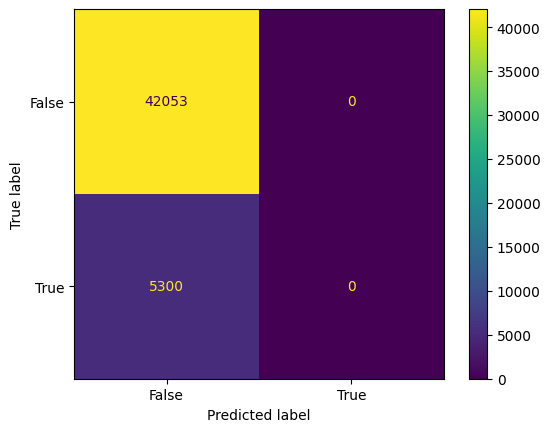

In [12]:
# coding: utf-8
print("Loading data...")

y_train = train_df['label'].reset_index(drop=True)
y_valid = valid_df['label'].reset_index(drop=True)
y_test = test_df['label'].reset_index(drop=True)
X_train = train_df.drop('label', axis=1).reset_index(drop=True)
X_valid = valid_df.drop('label', axis=1).reset_index(drop=True)
X_test = test_df.drop('label', axis=1).reset_index(drop=True)

# specify your configurations as a dict
params = {
    "boosting_type": "gbdt",
    "num_leaves": 7,
    "learning_rate": 0.01,
    "verbose": 0,
    "max_depth": 3,
    "num_iterations": 50,
    "class_weight": {
        0: 1,
        1: 1.5
    }
}

print("Starting training...")
# train
clf = lgb.LGBMClassifier(**params)

clf.fit(X_train, y_train)

print("Starting predicting...")
# predict
y_pred_train = clf.predict_proba(X_train)[:, 1]
print("AUC: ", roc_auc_score(y_train, y_pred_train))

y_pred_train = y_pred_train > 0.65
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot()

print(classification_report(y_train, y_pred_train))

In [13]:
# def objective(trial):
#     dtrain = lgb.Dataset(X_train, label=y_train)

#     param = {
#         "objective": "binary",
#         "metric": "binary_logloss",
#         "verbosity": -1,
#         "boosting_type": "gbdt",
#         # "n_estimators": trial.suggest_int("n_estimators", 50, 200),
#         # "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
#         "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
#         "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 2, 256),
#         "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
#         "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
#         "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         # "max_depth": trial.suggest_int("max_depth", 2, 8),
#     }
#     gbm = lgb.train(param, dtrain)
#     preds = gbm.predict(X_valid)
#     auc = roc_auc_score(y_valid, preds)
#     best_prec = 0
#     best_threshold = 0.2
#     for t in range(20, 80, 1):
#         pred_labels = preds > t/100
#         if pred_labels.sum() < 15:
#             break
#         prec = precision_score(y_valid, pred_labels)
#         if prec > best_prec:
#             best_threshold = t/100
#             best_prec = prec
#     print('Best threshold:', best_threshold)
#     trial.set_user_attr('model', gbm)
#     trial.set_user_attr('best_threshold', best_threshold)
#     return auc

# def callback(study, trial):
#     if study.best_trial.number == trial.number:
#         study.set_user_attr(key="best_model", value=trial.user_attrs["model"])
#         study.set_user_attr(key="best_threshold", value=trial.user_attrs["best_threshold"])

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=100, callbacks=[callback])

# print("Number of finished trials: {}".format(len(study.trials)))

# print("Best trial:")
# trial = study.best_trial

# print("  Value: {}".format(trial.value))

In [14]:
# clf = study.user_attrs['best_model']
# best_threshold = study.user_attrs['best_threshold']

In [15]:
# y_pred_valid = clf.predict(X_valid)
# print("AUC: ", roc_auc_score(y_valid, y_pred_valid))

# y_pred_valid = y_pred_valid > best_threshold

# cm = confusion_matrix(y_valid, y_pred_valid)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()

# print(classification_report(y_valid, y_pred_valid))

In [16]:
# y_pred_test = clf.predict(X_test)
# print("AUC: ", roc_auc_score(y_test, y_pred_test))

# y_pred_test = y_pred_test > best_threshold

# cm = confusion_matrix(y_test, y_pred_test)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()

# print(classification_report(y_test, y_pred_test))

In [17]:
# _y = clf.predict(X_test)
# a = pd.DataFrame([y_test, _y]).T
# a.columns = ['y_test', 'y_pred']
# a.sort_values(by='y_pred', ascending=False).head(10)

In [18]:
# a.sort_values(by='y_pred', ascending=False).head(10)

## Rolling

In [20]:
from datetime import datetime, timedelta
st = datetime(2024, 6, 1)
ed = datetime(2025, 1, 25)

budget = 5
while st < ed:
    print('st:', st)
    train_df = all_df[all_df['time'] < st]
    valid_df = all_df[(all_df['time'] >= st) & (all_df['time'] < st + timedelta(days=14))]
    test_df = all_df[(all_df['time'] >= st + timedelta(days=14)) & (all_df['time'] < st + timedelta(days=21))]

    train_df.reset_index(drop=True, inplace=True)
    valid_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)

    train_df_close_cols = train_df['close']
    valid_df_close_cols = valid_df['close']
    test_df_close_cols = test_df['close']

    train_df_next_close_cols = train_df['next_close']
    valid_df_next_close_cols = valid_df['next_close']
    test_df_next_close_cols = test_df['next_close']

    if 'symbol' in train_df.columns:
        train_df_symbol_cols = train_df['symbol']
        valid_df_symbol_cols = valid_df['symbol']
        test_df_symbol_cols = test_df['symbol']

    if 'next_close' in train_df.columns:
        del train_df['next_close']
        del valid_df['next_close']
        del test_df['next_close']

    # train_df_label2_cols = train_df['label2']
    # valid_df_label2_cols = valid_df['label2']
    # test_df_label2_cols = test_df['label2']

    rm_cols = ['open', 'high', 'close', 'low', 'volume', 'time', 'label2', 'symbol', 'next_close']
    for c in rm_cols:
        if c in valid_df.columns:
            del test_df[c]
            del train_df[c]
            del valid_df[c]

    print("Loading data...")

    y_train = train_df['label']
    y_valid = valid_df['label']
    y_test = test_df['label']
    X_train = train_df.drop('label', axis=1)
    X_valid = valid_df.drop('label', axis=1)
    X_test = test_df.drop('label', axis=1)

    def objective(trial):
        dtrain = lgb.Dataset(X_train, label=y_train)

        param = {
            "objective": "binary",
            "metric": "binary_logloss",
            "verbosity": -1,
            "boosting_type": "gbdt",
            # "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            # "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 2, 256),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            # "max_depth": trial.suggest_int("max_depth", 2, 8),
        }
        gbm = lgb.train(param, dtrain)
        preds = gbm.predict(X_valid)
        auc = roc_auc_score(y_valid, preds)
        best_prec = 0
        best_threshold = 0.2
        for t in range(20, 80, 1):
            pred_labels = preds > t/100
            if pred_labels.sum() < 10:
                break
            prec = precision_score(y_valid, pred_labels)
            if prec > best_prec:
                best_threshold = t/100
                best_prec = prec
        print('Best threshold:', best_threshold)
        trial.set_user_attr('model', gbm)
        trial.set_user_attr('best_threshold', best_threshold)
        return (best_prec + auc) / 2

    def callback(study, trial):
        if study.best_trial.number == trial.number:
            study.set_user_attr(key="best_model", value=trial.user_attrs["model"])
            study.set_user_attr(key="best_threshold", value=trial.user_attrs["best_threshold"])

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, callbacks=[callback])

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    clf = study.user_attrs['best_model']
    best_threshold = study.user_attrs['best_threshold']
    if X_test.shape[0] == 0:
        st = st + timedelta(days=7)
        continue

    y_pred_test = clf.predict(X_test)

    print("AUC: ", roc_auc_score(y_test, y_pred_test))

    # y_pred_test = y_pred_test > best_threshold

    # cm = confusion_matrix(y_test, y_pred_test)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # disp.plot()

    # print(classification_report(y_test, y_pred_test))

    test_df['label'] = y_test
    test_df['label_pred'] = y_pred_test
    test_df['close'] = test_df_close_cols
    test_df['next_close'] = test_df_next_close_cols
    test_df['symbol'] = test_df_symbol_cols

    top5 = test_df.sort_values(by='label_pred', ascending=False).head(5)
    top5 = top5[top5['label_pred'] > best_threshold]
    new_budget = 0
    for i, row in top5.iterrows():
        print(row['symbol'], row['next_close'], row['close'])
        if not np.isnan(row['next_close']):
            new_budget += (row['next_close'] / row['close']-0.002) * (budget / top5.shape[0])
        else:
            new_budget += budget / top5.shape[0]

    if top5.shape[0] == 0:
        new_budget = budget

    budget = new_budget
    st = st + timedelta(days=7)

    print('Current budget:', budget)

[I 2025-01-30 11:20:08,706] A new study created in memory with name: no-name-2e3c00e0-a2da-485d-8ea3-9a0ed4d0f44e


st: 2024-06-01 00:00:00
Loading data...


[I 2025-01-30 11:20:10,646] Trial 0 finished with value: 0.43277539358465683 and parameters: {'lambda_l1': 0.5310076433319574, 'lambda_l2': 7.683449415395998e-06, 'num_leaves': 44, 'feature_fraction': 0.9793539823568927, 'bagging_fraction': 0.8978730200509117, 'bagging_freq': 2, 'min_child_samples': 50}. Best is trial 0 with value: 0.43277539358465683.


Best threshold: 0.23


[I 2025-01-30 11:20:12,256] Trial 1 finished with value: 0.47225242628601827 and parameters: {'lambda_l1': 1.9959706070617622, 'lambda_l2': 0.12602958201503003, 'num_leaves': 58, 'feature_fraction': 0.8244208543239397, 'bagging_fraction': 0.40707338899060075, 'bagging_freq': 3, 'min_child_samples': 60}. Best is trial 1 with value: 0.47225242628601827.


...

Best threshold: 0.2


[I 2025-01-30 12:15:54,310] Trial 48 finished with value: 0.20032840722495895 and parameters: {'lambda_l1': 0.03466924172734039, 'lambda_l2': 7.769178862182322, 'num_leaves': 97, 'feature_fraction': 0.5445916760199558, 'bagging_fraction': 0.6002394477219158, 'bagging_freq': 1, 'min_child_samples': 73}. Best is trial 10 with value: 0.38177339901477836.


Best threshold: 0.2


[I 2025-01-30 12:15:55,319] Trial 49 finished with value: 0.2553366174055829 and parameters: {'lambda_l1': 4.087832163388233e-05, 'lambda_l2': 9.532135200915978e-06, 'num_leaves': 75, 'feature_fraction': 0.4235799925499617, 'bagging_fraction': 0.7451518616197976, 'bagging_freq': 2, 'min_child_samples': 84}. Best is trial 10 with value: 0.38177339901477836.


Best threshold: 0.2
Number of finished trials: 50
Best trial:
  Value: 0.38177339901477836
